<a href="https://colab.research.google.com/github/AadilaAnees/stroke_prediction/blob/main/stroke_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("healthcare_data.csv")

Exploratory Data Analysis

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9722 entries, 0 to 9721
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         9722 non-null   int64  
 1   patient_id         9722 non-null   int64  
 2   gender             9722 non-null   object 
 3   age                9722 non-null   float64
 4   has_hypertension   9722 non-null   int64  
 5   has_heart_disease  9722 non-null   int64  
 6   marital_status     9722 non-null   int64  
 7   employment_type    9722 non-null   object 
 8   residence          9722 non-null   object 
 9   glucose_level      9722 non-null   float64
 10  bmi_value          8795 non-null   float64
 11  smoking_habit      9722 non-null   object 
 12  stroke_event       9722 non-null   int64  
 13  age_group          9722 non-null   object 
 14  risk_score         9722 non-null   int64  
 15  high_glucose       9722 non-null   int64  
 16  bmi_category       9722 

In [4]:
df.describe()

,Unnamed: 0,patient_id,age,has_hypertension,has_heart_disease,marital_status,glucose_level,bmi_value,stroke_event,risk_score,high_glucose
count,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,9722.000000,8795.000000,9722.000000,9722.000000,9722.000000
mean,4861.500000,36558.933553,54.895943,0.182781,0.115717,0.762497,119.022954,29.594031,0.500000,0.298498,0.267023
std,2806.643992,21625.116836,22.316333,0.386507,0.319902,0.425575,55.540275,7.278338,0.500026,0.526214,0.442427
min,1.000000,67.000000,0.080000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000,0.000000,0.000000
25%,2431.250000,17004.000000,41.000000,0.000000,0.000000,1.000000,78.265000,24.800000,0.000000,0.000000,0.000000
50%,4861.500000,36771.500000,59.000000,0.000000,0.000000,1.000000,96.760000,28.600000,0.500000,0.000000,0.000000
75%,7291.750000,55605.000000,75.000000,0.000000,0.000000,1.000000,151.160000,33.400000,1.000000,1.000000,1.000000
max,9722.000000,72940.000000,82.000000,1.000000,1.000000,1.000000,271.740000,97.600000,1.000000,2.000000,1.000000


In [5]:
df.head()

,Unnamed: 0,patient_id,gender,age,has_hypertension,has_heart_disease,marital_status,employment_type,residence,glucose_level,bmi_value,smoking_habit,stroke_event,age_group,risk_score,high_glucose,bmi_category,lifestyle_risk
0,1,30669,M,3.0,0,0,0,other,Rural,95.12,18.0,unknown,0,young,0,0,underweight,low
1,2,30468,M,58.0,1,0,1,working,Urban,87.96,39.2,non_smoker,0,middle,1,0,obese,low
2,3,16523,F,8.0,0,0,0,working,Urban,110.89,17.6,unknown,0,young,0,0,underweight,low
3,4,56543,F,70.0,0,0,1,working,Rural,69.04,35.9,ex_smoker,0,senior,0,0,obese,medium
4,5,46136,M,14.0,0,0,0,other,Rural,161.28,19.1,unknown,0,young,0,1,normal,low


In [6]:
df = df.drop(['Unnamed: 0'], axis=1)
df = df.set_index('patient_id')

In [7]:
df.head()

,gender,age,has_hypertension,has_heart_disease,marital_status,employment_type,residence,glucose_level,bmi_value,smoking_habit,stroke_event,age_group,risk_score,high_glucose,bmi_category,lifestyle_risk
patient_id,,,,,,,,,,,,,,,,
30669,M,3.0,0,0,0,other,Rural,95.12,18.0,unknown,0,young,0,0,underweight,low
30468,M,58.0,1,0,1,working,Urban,87.96,39.2,non_smoker,0,middle,1,0,obese,low
16523,F,8.0,0,0,0,working,Urban,110.89,17.6,unknown,0,young,0,0,underweight,low
56543,F,70.0,0,0,1,working,Rural,69.04,35.9,ex_smoker,0,senior,0,0,obese,medium
46136,M,14.0,0,0,0,other,Rural,161.28,19.1,unknown,0,young,0,1,normal,low


In [8]:
minimum_age_patient = df[df['age'] == df['age'].min()]

In [9]:
display(minimum_age_patient)

,gender,age,has_hypertension,has_heart_disease,marital_status,employment_type,residence,glucose_level,bmi_value,smoking_habit,stroke_event,age_group,risk_score,high_glucose,bmi_category,lifestyle_risk
patient_id,,,,,,,,,,,,,,,,
47350,F,0.08,0,0,0,other,Urban,139.67,14.1,unknown,0,young,0,0,underweight,low
29955,M,0.08,0,0,0,other,Rural,70.33,16.9,unknown,0,young,0,0,underweight,low


In [10]:
df.isnull().sum()

,0
gender,0
age,0
has_hypertension,0
has_heart_disease,0
marital_status,0
employment_type,0
residence,0
glucose_level,0
bmi_value,927
smoking_habit,0


In [11]:
df['stroke_event'].value_counts(normalize=True)

,proportion
stroke_event,
0,0.5
1,0.5


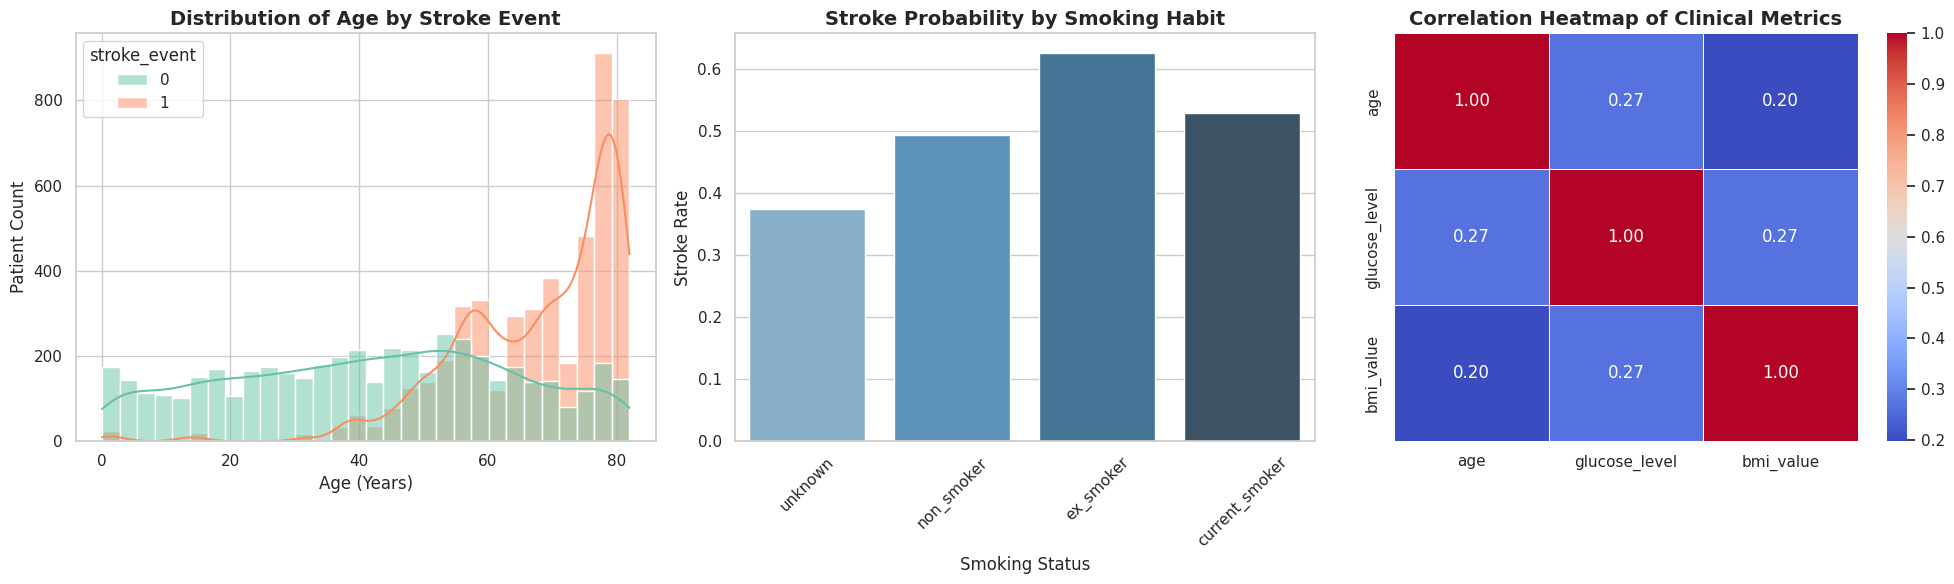

In [12]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# ---------------------------------------------------------
# Chart 1: Histogram of Age grouped by Stroke Event
# ---------------------------------------------------------

sns.histplot(data=df, x='age', hue='stroke_event', bins=30, kde=True, palette='Set2', ax=axes[0])
axes[0].set_title('Distribution of Age by Stroke Event', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age (Years)')
axes[0].set_ylabel('Patient Count')

# ---------------------------------------------------------
# Chart 2: Stroke Rate across Smoking Habits
# ---------------------------------------------------------
sns.barplot(data=df, x='smoking_habit', y='stroke_event',
            palette='Blues_d', ax=axes[1], errorbar=None)
axes[1].set_title('Stroke Probability by Smoking Habit', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Smoking Status')
axes[1].set_ylabel('Stroke Rate')
axes[1].tick_params(axis='x', rotation=45)


# ---------------------------------------------------------
# Chart 3: Correlation Heatmap of Continuous Variables
# ---------------------------------------------------------
# Select only the continuous mathematical variables
continuous_vars = df[['age', 'glucose_level', 'bmi_value']]
correlation_matrix = continuous_vars.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',
            fmt=".2f", linewidths=0.5, ax=axes[2])
axes[2].set_title('Correlation Heatmap of Clinical Metrics', fontsize=14, fontweight='bold')

# Adjust layout so nothing overlaps and display
plt.tight_layout()
plt.show()

Data Preparation

In [13]:
print("Missing BMI before:", df['bmi_value'].isnull().sum())

Missing BMI before: 927


In [14]:
#replace missing values with median of person's gender and age group
df['bmi_value'] = df.groupby(['gender','age_group'])['bmi_value'].transform(lambda x:x.fillna(x.median() ))
#if an age group/gender has no median
df['bmi_category'] = df['bmi_value'].fillna(df['bmi_value'].median())


In [15]:
print("Missing BMI after:", df['bmi_value'].isnull().sum())

Missing BMI after: 0


Statistical Hypothesis Testing

In [16]:
from scipy.stats import chi2_contingency, ttest_ind

In [17]:
#Test 1: Chi-Square Test (Smoking Habit vs. Stroke Event)

#null Hypothesis: Smoking habit and stroke risk are entirely independent.

contingency_table = pd.crosstab(df['smoking_habit'], df['stroke_event'])
chi2, p, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Test: Smoking vs Stroke")
print("Chi-Square Statistic:", chi2)
print("P-value:", p)

if p < 0.05:
    print("Result: Statistically Significant (Reject Null Hypothesis)\n")
else:
    print("Result: Not Significant\n")

Chi-Square Test: Smoking vs Stroke
Chi-Square Statistic: 294.24136741170196
P-value: 1.7541201929903772e-63
Result: Statistically Significant (Reject Null Hypothesis)



In [18]:
from sys import set_coroutine_origin_tracking_depth
#Test 2: Independent T-Test (Age vs. Stroke Event)

#null Hypothesis: There is no difference in the average age of patients who had a stroke vs those who didn't.
stroke_age = df[df['stroke_event'] == 1]['age']
no_stroke_age = df[df['stroke_event'] == 0]['age']

t_stat, p_value = ttest_ind(stroke_age, no_stroke_age)

print("Independent T-Test: Age vs Stroke")
print("T-Statistic:", t_stat)
print("P-value:", p_value)

if p_value < 0.05:
    print("Result: Statistically Significant (Reject Null Hypothesis)\n")
else:
    print("Result: Not Significant\n")


Independent T-Test: Age vs Stroke
T-Statistic: 70.04499382674365
P-value: 0.0
Result: Statistically Significant (Reject Null Hypothesis)



Feature Engineering

In [19]:
categorical_columns = df.select_dtypes(include=['object']).columns
print (categorical_columns)

Index(['gender', 'employment_type', 'residence', 'smoking_habit', 'age_group',
       'lifestyle_risk'],
      dtype='object')


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

In [21]:
#Feature Selection - Drop redundant categorical features and the target variable
X = df.drop(['stroke_event', 'age_group', 'bmi_category', 'high_glucose', 'lifestyle_risk', 'risk_score'], axis=1)
y = df['stroke_event']

In [22]:
#One-Hot Encoding - Convert text categories into binary (0/1) columns
X_encoded = pd.get_dummies(X, drop_first=True)

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42, stratify=y)

In [24]:
#Feature Scaling - Standardize continuous variables so large numbers (glucose)
scaler = StandardScaler()

#continuous columns to scale
continuous_cols = ['age', 'glucose_level', 'bmi_value']

X_train[continuous_cols] = scaler.fit_transform(X_train[continuous_cols])
X_test[continuous_cols] = scaler.transform(X_test[continuous_cols])

print("Data successfully preprocessed. Training feature shape:", X_train.shape)

Data successfully preprocessed. Training feature shape: (7777, 13)


In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

In [26]:
#Model 1: Logistic Regression (Baseline)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)
y_pred_log = log_reg.predict(X_test)

print("Logistic Regression Performance")
print(classification_report(y_test, y_pred_log))
print("ROC-AUC Score:", roc_auc_score(y_test, log_reg.predict_proba(X_test)[:, 1]))

Logistic Regression Performance
              precision    recall  f1-score   support

           0       0.79      0.75      0.77       973
           1       0.76      0.80      0.78       972

    accuracy                           0.78      1945
   macro avg       0.78      0.78      0.78      1945
weighted avg       0.78      0.78      0.78      1945

ROC-AUC Score: 0.8540691256518594


In [27]:
# Model 2: Random Forest Classifier (Advanced)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("Random Forest Performance")
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC Score:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]))

Random Forest Performance
              precision    recall  f1-score   support

           0       0.99      0.89      0.93       973
           1       0.90      0.99      0.94       972

    accuracy                           0.94      1945
   macro avg       0.94      0.94      0.94      1945
weighted avg       0.94      0.94      0.94      1945

ROC-AUC Score: 0.9917420560905773


Feature Importance

In [28]:
importances = rf_model.feature_importances_

feature_names = X_train.columns
importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

importance_df = importance_df.sort_values(by='Importance', ascending=False)

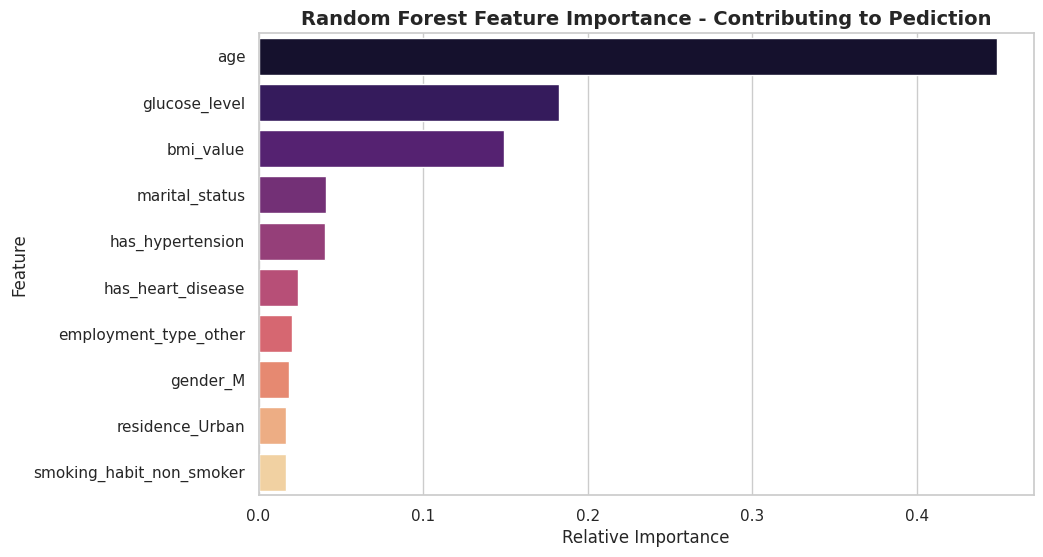

In [29]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='magma')
plt.title('Random Forest Feature Importance - Contributing to Pediction', fontsize=14,fontweight='bold')
plt.xlabel('Relative Importance')
plt.ylabel('Feature')
plt.show()

Depth of Analysis

In [30]:
#to break down exactly how the model makes decisions
import shap

In [31]:
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)

In [32]:
stroke_shap_values = shap_values[:, :, 1]

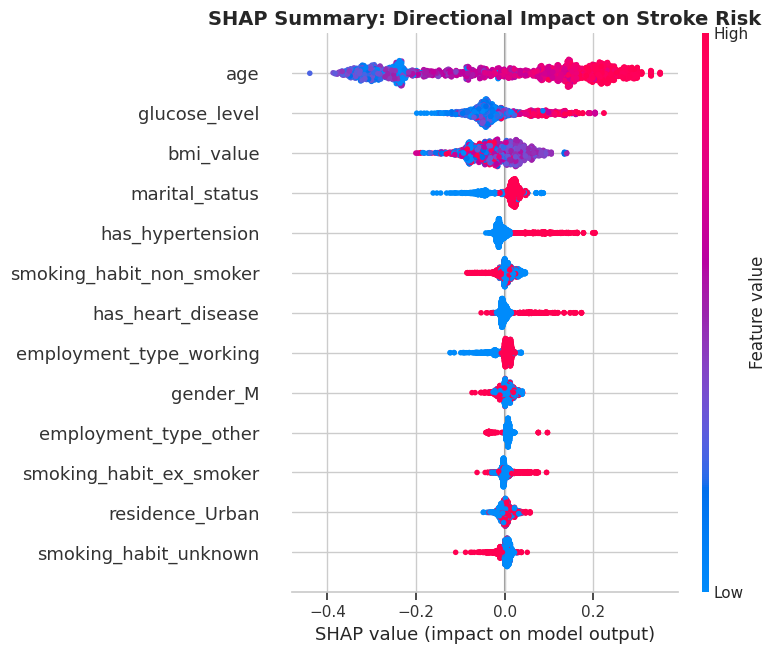

In [33]:
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary: Directional Impact on Stroke Risk", fontsize=14, fontweight='bold')
shap.summary_plot(stroke_shap_values, X_test, show=False)
plt.tight_layout()
plt.show()